In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import cospar
import scanpy as sc
import PINN 
import numpy as np
import pandas as pd

import palantir
from PINN import tl

import seaborn as sns
import matplotlib.pyplot as plt

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/torch/cuda/__init__.py:749: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


In [3]:
os.chdir("../../")

```
wget http://wangshouwen.lab.westlake.edu.cn/app/filebrowser/api/public/dl/rLFbKIvS/Complete_LARRY_dataset_adata_preprocessed.h5ad
```

In [3]:
larry = sc.read_h5ad("data/Complete_LARRY_dataset_adata_preprocessed.h5ad")
larry.obs['timepoint'] = larry.obs['Time_Point'].astype(float)
larry

AnnData object with n_obs × n_vars = 130887 × 25289
    obs: 'n_counts', 'Time_Point', 'Source', 'Well', 'mito_frac', 'time_info', 'state_info', 'precomputed_fate_bias', 'selected_clonal_cells', 'Gata1_states'
    var: 'highly_variable'
    uns: 'clonal_time_points', 'data_des', 'max_mito', 'min_tot', 'neighbors', 'popD', 'state_info_colors', 'time_info_colors', 'time_ordering', 'umap'
    obsm: 'X_clone', 'X_emb', 'X_pca', 'X_umap'

In [ ]:
larry.obs['selected_clonal_cells'].sum()

49116

In [6]:
std2 = np.std([24000, 30000, 36000])
std4 = np.std([120000, 150000, 180000])
std6 = np.std([300000, 450000, 750000])

popD = {
    "mean" : np.array([24000, 30000, 36000]),
    "var" : np.array([int(std2), int(std4), int(std6)]),
    "t" : np.array([2,4,6]),
    "n_lib": np.array([3,3,3])
}

In [7]:
larry.uns['pop'] = popD

# diffusion map

In [6]:
import palantir

In [7]:
# Run diffusion maps
dm_res = palantir.utils.run_diffusion_maps(larry)
ms_data = palantir.utils.determine_multiscale_space(larry)

In [ ]:
larry.obsm['DM_EigenVectors_multiscaled'].min(axis=0)

array([-2.5467803 , -2.6601565 , -9.855604  , -0.49657667, -1.0085257 ],
      dtype=float32)

In [14]:
ms_data.shape

(130887, 5)

In [8]:
larry.write_h5ad("data/Complete_LARRY_dataset_adata_preprocessed.h5ad")

# resume

In [23]:
%load_ext autoreload
%autoreload 2

In [20]:
from PINN import reader
import palantir

In [135]:
larry = sc.read_h5ad("data/Complete_LARRY_dataset_adata_preprocessed.h5ad")
larry

AnnData object with n_obs × n_vars = 130887 × 25289
    obs: 'n_counts', 'Time_Point', 'Source', 'Well', 'mito_frac', 'time_info', 'state_info', 'precomputed_fate_bias', 'selected_clonal_cells', 'Gata1_states', 'timepoint'
    var: 'highly_variable'
    uns: 'DM_EigenValues', 'clonal_time_points', 'data_des', 'max_mito', 'min_tot', 'neighbors', 'pop', 'popD', 'state_info_colors', 'time_info_colors', 'time_ordering', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_clone', 'X_emb', 'X_pca', 'X_umap'
    obsp: 'DM_Kernel', 'DM_Similarity'

In [14]:
subset_ad = larry[larry.obs['selected_clonal_cells']].copy()
subset_ad

AnnData object with n_obs × n_vars = 49116 × 25289
    obs: 'n_counts', 'Time_Point', 'Source', 'Well', 'mito_frac', 'time_info', 'state_info', 'precomputed_fate_bias', 'selected_clonal_cells', 'Gata1_states', 'timepoint'
    var: 'highly_variable'
    uns: 'DM_EigenValues', 'clonal_time_points', 'data_des', 'max_mito', 'min_tot', 'neighbors', 'pop', 'popD', 'state_info_colors', 'time_info_colors', 'time_ordering', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_clone', 'X_emb', 'X_pca', 'X_umap'
    obsp: 'DM_Kernel', 'DM_Similarity'

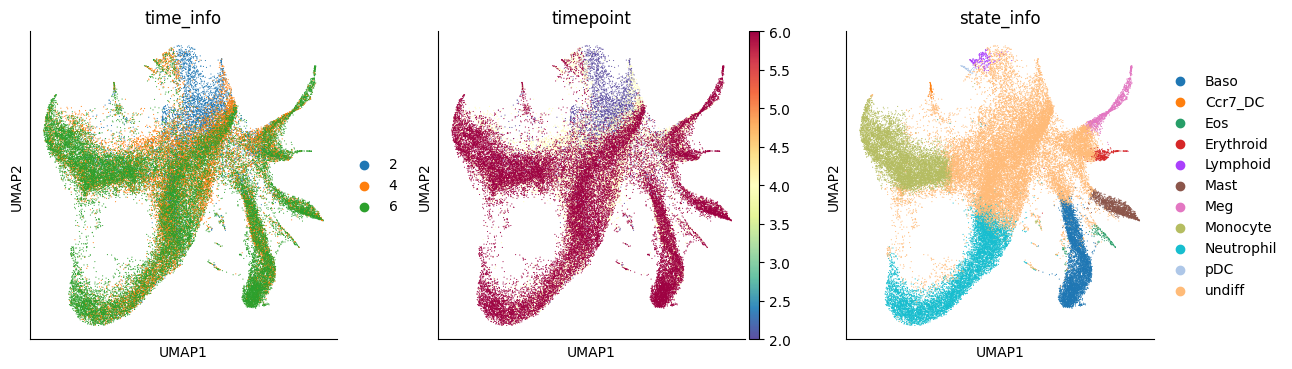

In [21]:
sc.pl.umap(subset_ad, color=['time_info', 'timepoint', 'state_info'])

In [62]:
train_DS = reader.HigDim_AnnDS(AnnData=subset_ad, 
                cellstate_key = 'DM_EigenVectors_multiscaled',
                timepoint_key = 'timepoint',
                nearby_cellstate=1, n_dimension=5, 
                n_timepoint=3, 
                kde_kws = {'bw_method':1.5}
                )

In [87]:
u_b = train_DS.u_b.reshape(3, -1).numpy()
for i in range(3):
    t = popD['t'][i]
    subset_ad.obs[f'Day{t}_u_bw1.5'] = u_b[i]

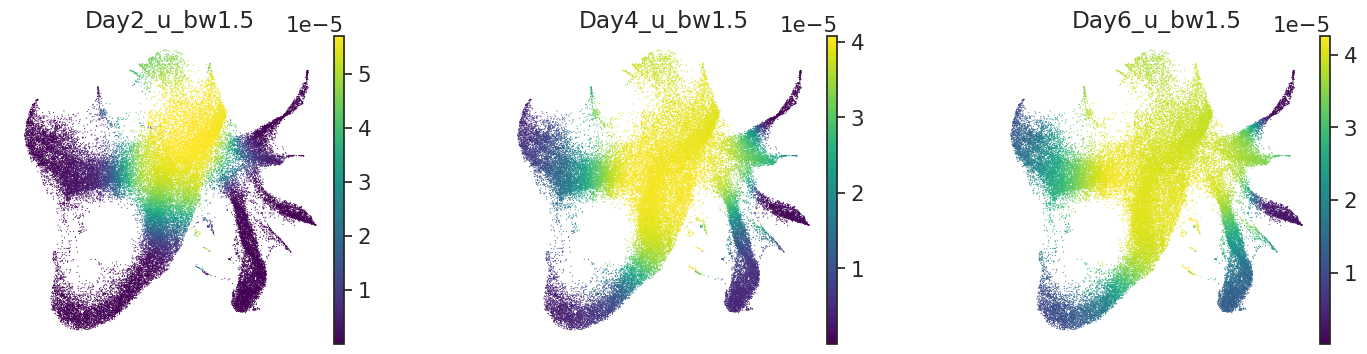

In [88]:
sns.set_theme(style='ticks', font_scale=1.4)
sc.pl.umap(subset_ad, color=[f'Day{t}_u_bw1.5' for t in popD['t']], color_map='viridis', frameon=False, wspace=0.4)

In [54]:
obs = subset_ad.obs.copy()

In [33]:
obs = update.obs.copy()

0

In [44]:
def count_celltype(obs, timepoint_key='Time_Point', celltype_key='state_info', density_col_fn = lambda t : f'Day{int(float(t))}_u'):
    """
    Count cell proportion and density by time and celltype

    Arguments:
    --------
    obs : observation dataframe, `obs = adata.obs.copy()`
    timepoint_key : indicate the timepoint
    celltype_key : 
    """
    count_df = []
    
    # find any column that is category to count cells
    col_dtypes = obs.dtypes
    col1 = col_dtypes.index[np.where(col_dtypes == 'category')[0][0]]

    for t in sorted(obs[timepoint_key].unique()):

        density_col = density_col_fn(t)

        df = obs.query(f"`{timepoint_key}` == @t").groupby([celltype_key]).agg({col1:'count', density_col:'sum'}).reset_index()
        df[timepoint_key] = t
        df['proportion'] = df[col1] / df[col1].sum()
        df = df.rename({density_col:'density'}, axis=1)
        df['density'] = df['density'] / df['density'].sum()
        count_df.append(df)

    count_df = pd.concat(count_df, axis=0).reset_index()
    count_df = count_df.rename({col1:"count"}, axis=1)
    count_df['log_count'] = np.log(count_df['count'])
    count_df['log_proportion'] = np.log(count_df['proportion'])
    count_df['log_density'] = np.log(count_df['density'])

    return count_df

In [130]:
def plot_proportion_density(count_df, timepoint_key='Time_Point', celltype_key='state_info'):
    """
    visualize the result
    """

    # compare log proportion and log density
    fig , axs= plt.subplots(2,1,figsize=(9,6), sharex=True)
    sns.barplot(data=count_df, x=celltype_key, y='log_proportion', hue=timepoint_key, ax=axs[0])
    sns.barplot(data=count_df, x=celltype_key, y='log_density', hue=timepoint_key, ax=axs[1])
    axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=90);
    axs[1].set_xlabel("")
    axs[0].legend("", frameon=False)


    # split celltypes by max pro
    max_pro = count_df.groupby(celltype_key).agg({"proportion":"max"})
    thres = np.quantile(max_pro.values.flatten(), [0, 0.34, 0.67, 1])
    thres[0] = 0
    groups = pd.cut(max_pro.values.flatten(), thres, labels=False)

    # figure layout
    n_group = len(np.unique(groups))
    fig2 , axs2= plt.subplots(2, n_group, figsize=(n_group*3+3,6), gridspec_kw={'wspace':0.3})

    for i, g in enumerate(np.unique(groups)):
        col = max_pro.index[np.where(groups==g)[0]]
        g_df = count_df.query(f"`{celltype_key}` in @col")
        g_df[celltype_key] = g_df[celltype_key].astype(str)

        print(len(max_pro.index), g_df[celltype_key].nunique())

        sns.barplot(data=g_df, x=celltype_key, y='proportion', hue=timepoint_key, ax=axs2[0,i])
        sns.barplot(data=g_df, x=celltype_key, y='density', hue=timepoint_key, ax=axs2[1,i])
        axs2[0,i].set_xticklabels([]);
        axs2[1,i].set_xticklabels(axs2[1,i].get_xticklabels(), rotation=90);
        axs2[0,i].set_xlabel("")
        axs2[1,i].set_xlabel("")
        axs2[0,i].legend("", frameon=False)
        axs2[1,i].legend("", frameon=False)

        if i!= 0:
            axs2[0,i].set_ylabel("")
            axs2[1,i].set_ylabel("")

    return fig, fig2

In [30]:
count_df = count_celltype(subset_ad, celltype_key='state_info', timepoint_key='Time_Point')
count_df.head()

NameError: name 'count_df' is not defined

In [ ]:
f1,f2 = plot_proportion_density(count_df, celltype_key='state_info', timepoint_key='Time_Point')

# mingze's adata

In [84]:
mingze_excl = pd.read_excel("data/Weinreb/mingze_weinreb.xlsx")
mingze_excl.to_csv("data/Weinreb/mingze_weinreb.csv")
mingze_excl.head(3)

,Unnamed: 0,prog_1,prog_2,prog_3,prog_4,prog_Baso_Meg_Ery_Mast,prog_Baso_Eos,prog_DC_Mono,prog_Ly_pDC,prog_Meg_Ery,...,Baso,DC,Eos,Ery,Ly,Mast,Meg,Mono,Neu,pDC
0,prog_1,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,prog_2,NaN,NaN,1.0,1.0,1.0,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,prog_3,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
update = sc.read_h5ad("data/Weinreb/klein_update.h5ad")

In [64]:
update

AnnData object with n_obs × n_vars = 126861 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'Time_point_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [80]:
update.uns['neighbors']

{'connectivities_key': 'connectivities',
 'distances_key': 'distances',
 'params': {'method': 'umap',
  'metric': 'euclidean',
  'n_neighbors': 15,
  'n_pcs': 50,
  'random_state': 0}}

In [81]:
# Run diffusion maps
sc.tl.diffmap(update, n_comps=10)
dm_res = palantir.utils.run_diffusion_maps(update, knn=15)
ms_data = palantir.utils.determine_multiscale_space(update)

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/scanpy/neighbors/__init__.py:743: RuntimeWarning: divide by zero encountered in divide
  Q = scipy.sparse.spdiags(1.0 / q, 0, W.shape[0], W.shape[0])
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/scanpy/neighbors/__init__.py:753: RuntimeWarning: divide by zero encountered in divide
  self.Z = scipy.sparse.spdiags(1.0 / z, 0, K.shape[0], K.shape[0])


In [82]:
update.uns['pop'] = popD

In [143]:
update.write_h5ad("data/klein_addpop.h5ad")

## plot

In [67]:
sns.set_theme(style='ticks', font_scale=1)

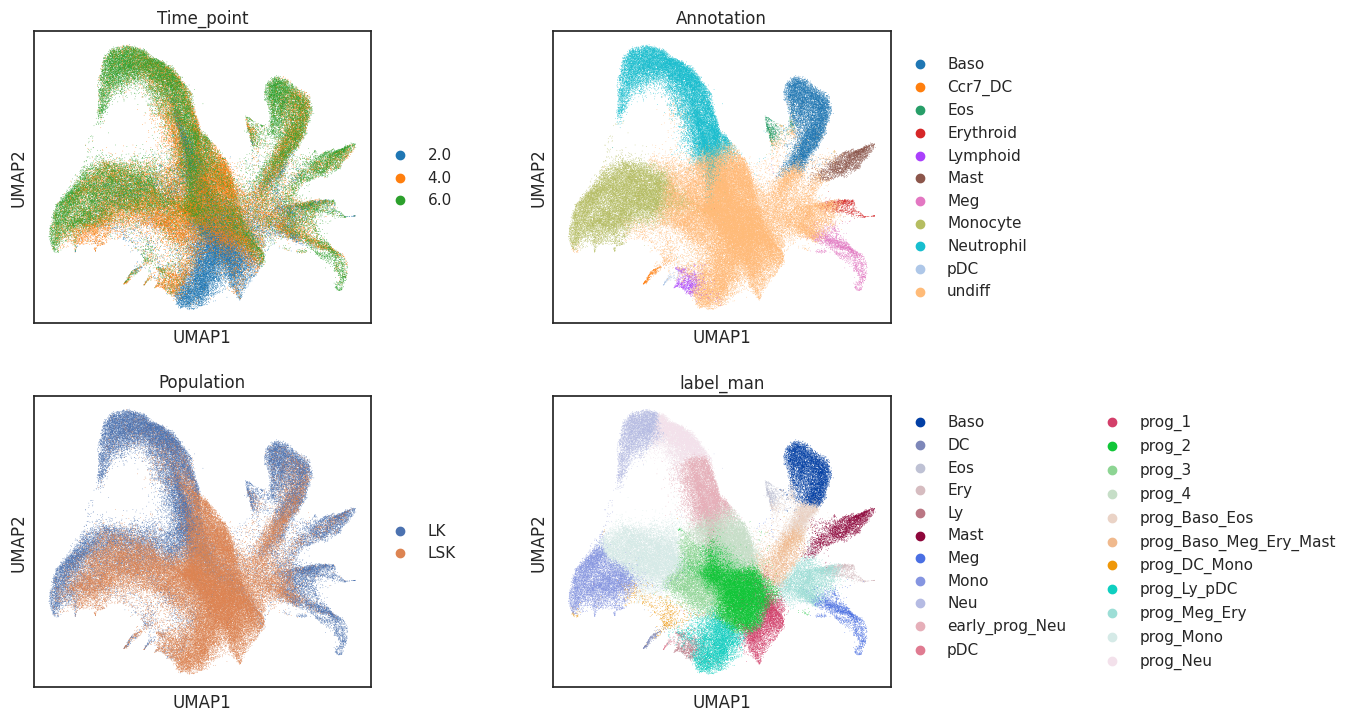

In [69]:
sc.pl.umap(update, color=['Time_point', 'Annotation', 'Population', 'label_man'], ncols=2, wspace=0.4, frameon=False)

In [5]:
sns.set_theme(style='ticks', font_scale=0.9, rc={'figure.dpi':200, 'figure.figsize':[4,4]})
sc.pl.umap(update, color='label_man', legend_loc='on data', frameon=False, legend_fontsize=7)

NameError: name 'update' is not defined

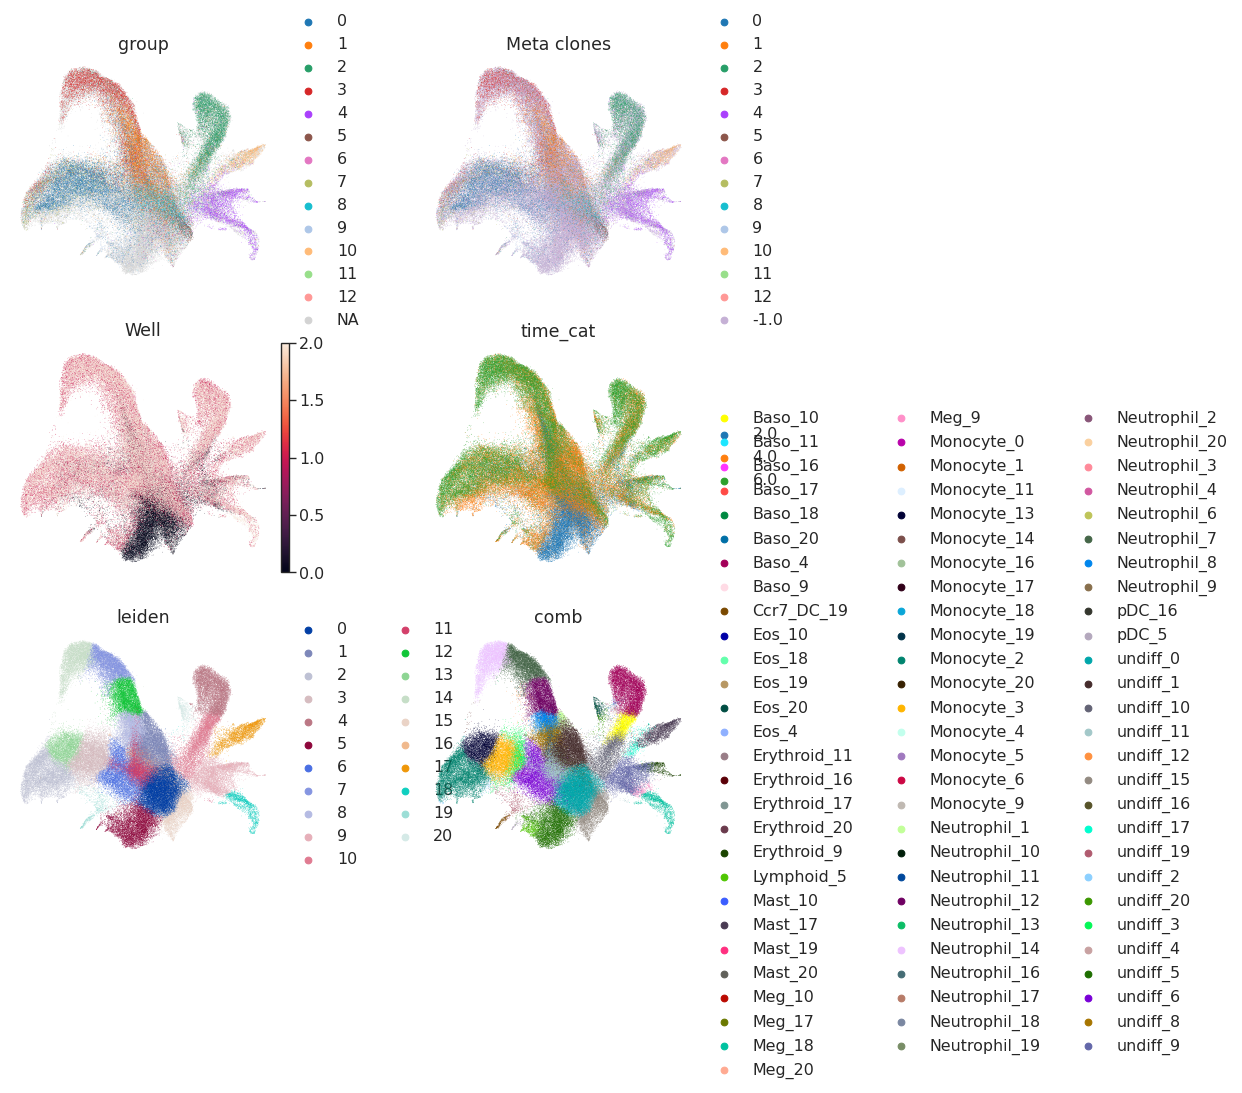

In [55]:
sns.set_theme(style='ticks', font_scale=1.3, rc={'figure.dpi':80, 'figure.figsize':[4,4]})
sc.pl.umap(update, color=['group', 'Meta clones', 'Well', 'time_cat', 'leiden', 'comb'], ncols=2, wspace=0.4, frameon=False)

# resume

In [9]:
from PINN import reader

In [133]:
update = sc.read_h5ad("data/klein_addpop.h5ad")

In [142]:
update.obs['selected_clonal_cells'] = larry.obs.loc[update.obs_names, 'selected_clonal_cells'].copy()

In [138]:
np.intersect1d(update.obs_names, larry.obs_names)

array(['0', '1', '10', ..., '99997', '99998', '99999'], dtype=object)

In [12]:
popD = update.uns['pop']

## estimate density

In [145]:
subset_up = update[update.obs['selected_clonal_cells']].copy()
subset_up

AnnData object with n_obs × n_vars = 47907 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'DM_EigenValues', 'Meta clones_colors', 'Population_colors', 'Time_point_colors', 'comb_colors', 'diffmap_evals', 'group_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'pca', 'pop', 'time_cat_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

In [ ]:
condition = np.logical_and(subset_up.obs['label_man'] == 'prog_1', subset_up.obs.Time_point == '2.0')
# rootid = np.random.choice(np.where(condition)[0])
rootid = 16730

root_cb = subset_up.obs_names[rootid]

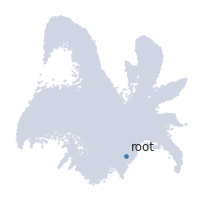

In [ ]:
all_states = pd.Series(
    ["root"],
    index=[root_cb],
)

sns.set_theme(style='ticks', font_scale=0.9, rc={'figure.dpi':80, 'figure.figsize':[3,3]})
palantir.plot.highlight_cells_on_umap(subset_up, all_states);

In [ ]:
pr_res = palantir.core.run_palantir(
    subset_up, root_cb, knn=15, num_waypoints=1500
)

Sampling and flocking waypoints...


Time for determining waypoints: 0.27381502787272133 minutes
Determining pseudotime...
Shortest path distances using 15-nearest neighbor graph...
Time for shortest paths: 1.3043205857276916 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


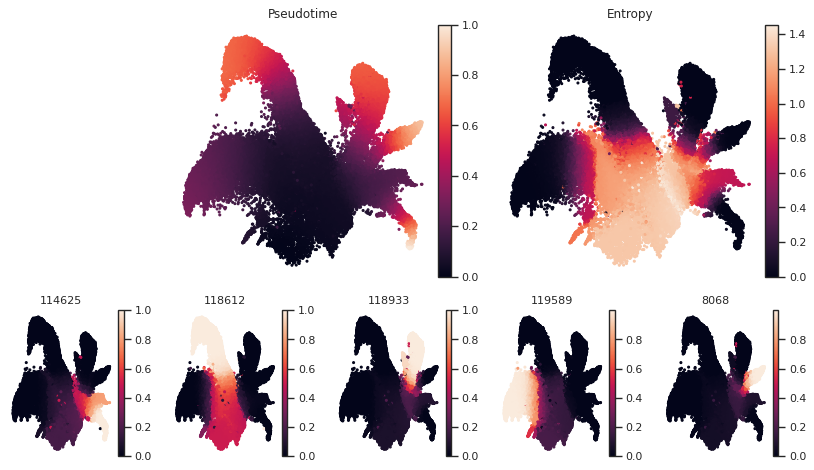

In [ ]:
palantir.plot.plot_palantir_results(subset_up, s=3);

In [58]:
subset_up.write_h5ad("data/klein_subset.h5ad")

In [146]:
trainDS = reader.HigDim_AnnDS(AnnData=subset_up, 
                cellstate_key = 'DM_EigenVectors_multiscaled',
                timepoint_key = 'timepoint_tx_days',
                nearby_cellstate=1, n_dimension=5, 
                n_timepoint=3, 
                # kde_kws = {'bw_method':1.5}
                )

In [147]:
u_b = trainDS.u_b.reshape(3, -1).numpy()
for i in range(3):
    t = popD['t'][i]
    subset_up.obs[f'Day{t}_u'] = u_b[i]

prediction of shape (3, 47907)


[None]

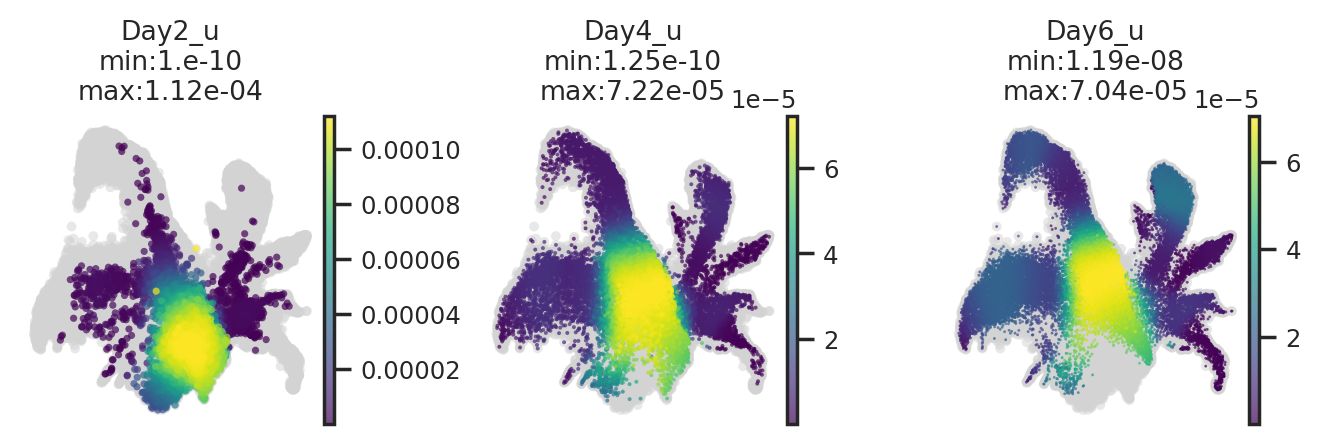

In [148]:
sns.set_theme(style='ticks', font_scale=0.8)
fig, axs = PINN.pl.params_in_umap(subset_up, u_b, timepoints=popD['t']);
fig.update({"dpi":200})

In [150]:
sum_df = count_celltype(subset_up.obs.copy(), celltype_key='label_man', timepoint_key='timepoint_tx_days')

/home/Wergillius/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/Wergillius/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/Wergillius/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


/tmp/ipykernel_1211540/567115304.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=90);
/tmp/ipykernel_1211540/567115304.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  g_df[celltype_key] = g_df[celltype_key].astype(str)
/tmp/ipykernel_1211540/567115304.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs2[1,i].set_xticklabels(axs2[1,i].get_xticklabels(), rotation=90);
/tmp/ipykernel_1211540/567115304.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

22 8
22 7


/tmp/ipykernel_1211540/567115304.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs2[1,i].set_xticklabels(axs2[1,i].get_xticklabels(), rotation=90);
/tmp/ipykernel_1211540/567115304.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  g_df[celltype_key] = g_df[celltype_key].astype(str)
/tmp/ipykernel_1211540/567115304.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs2[1,i].set_xticklabels(axs2[1,i].get_xticklabels(), rotation=90);


22 7


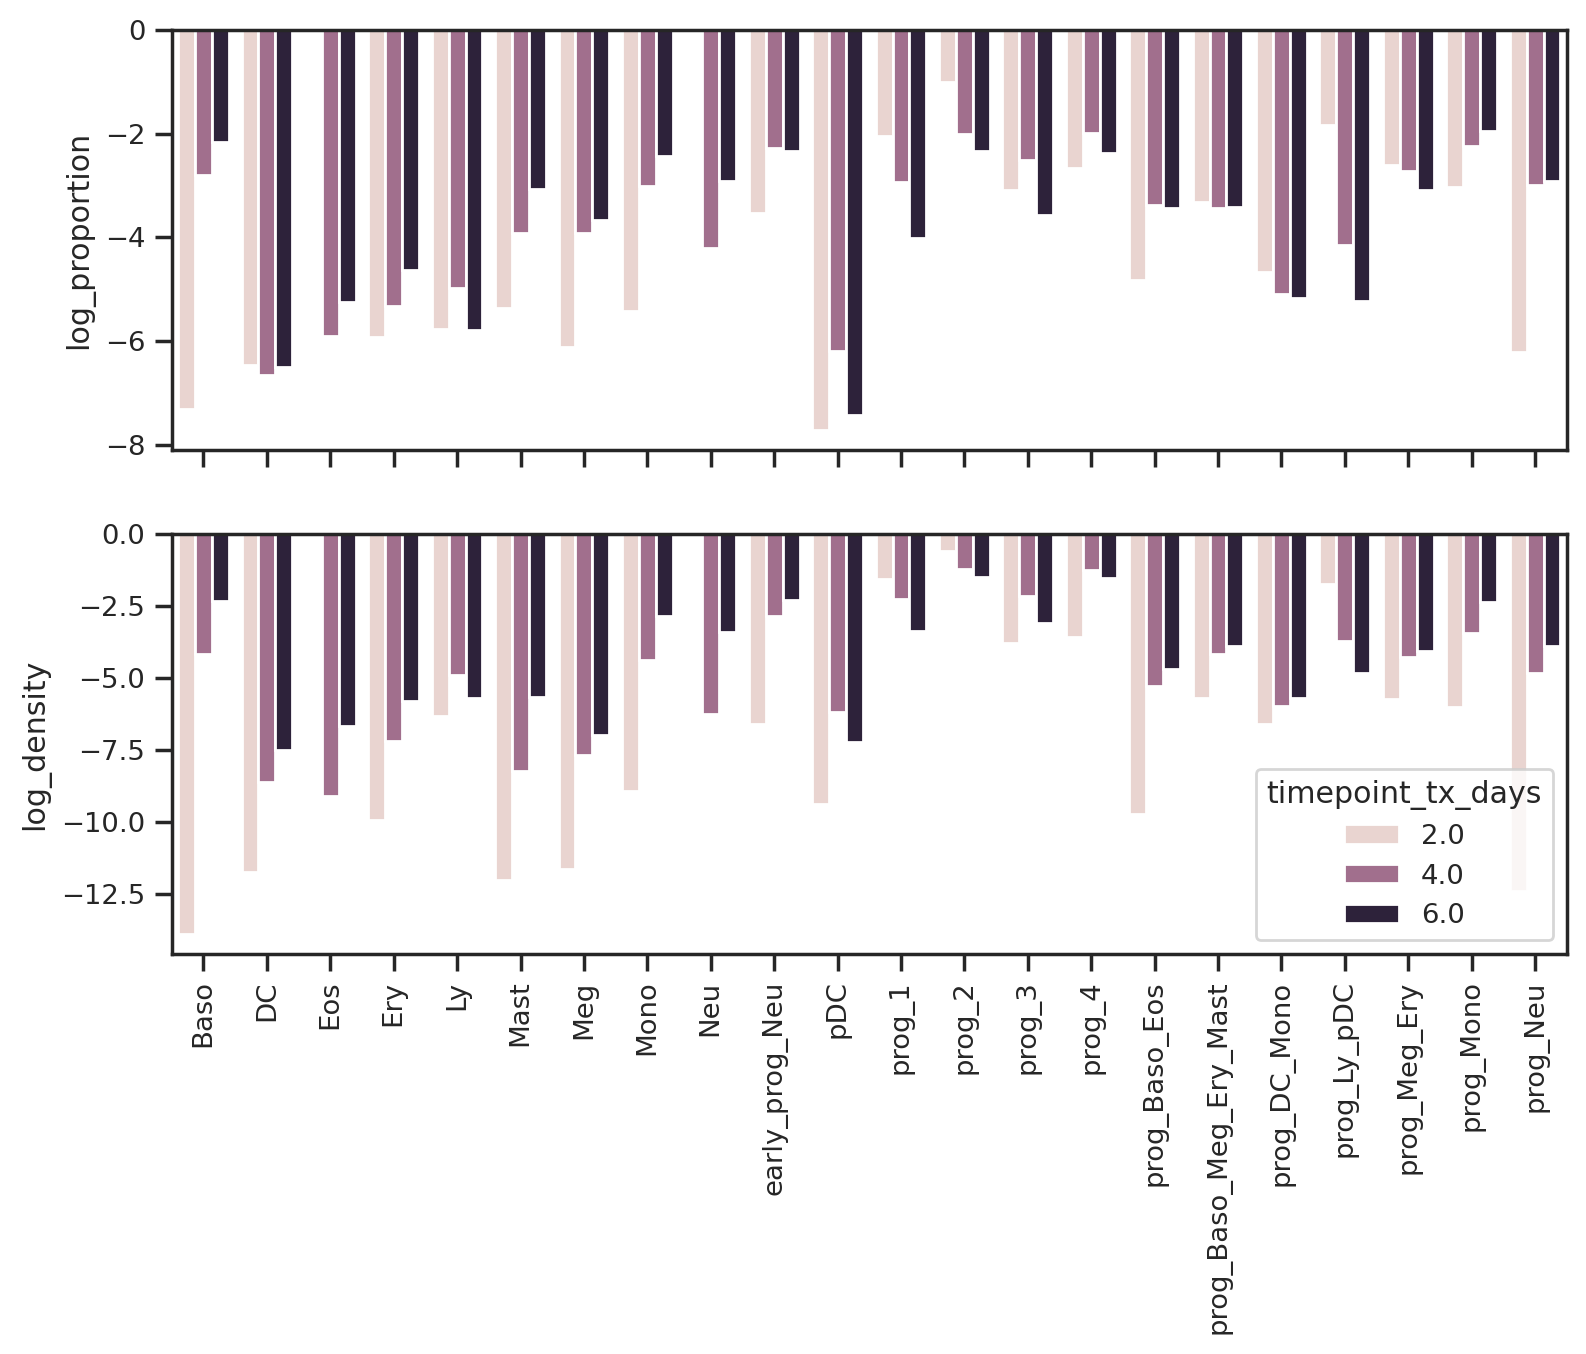

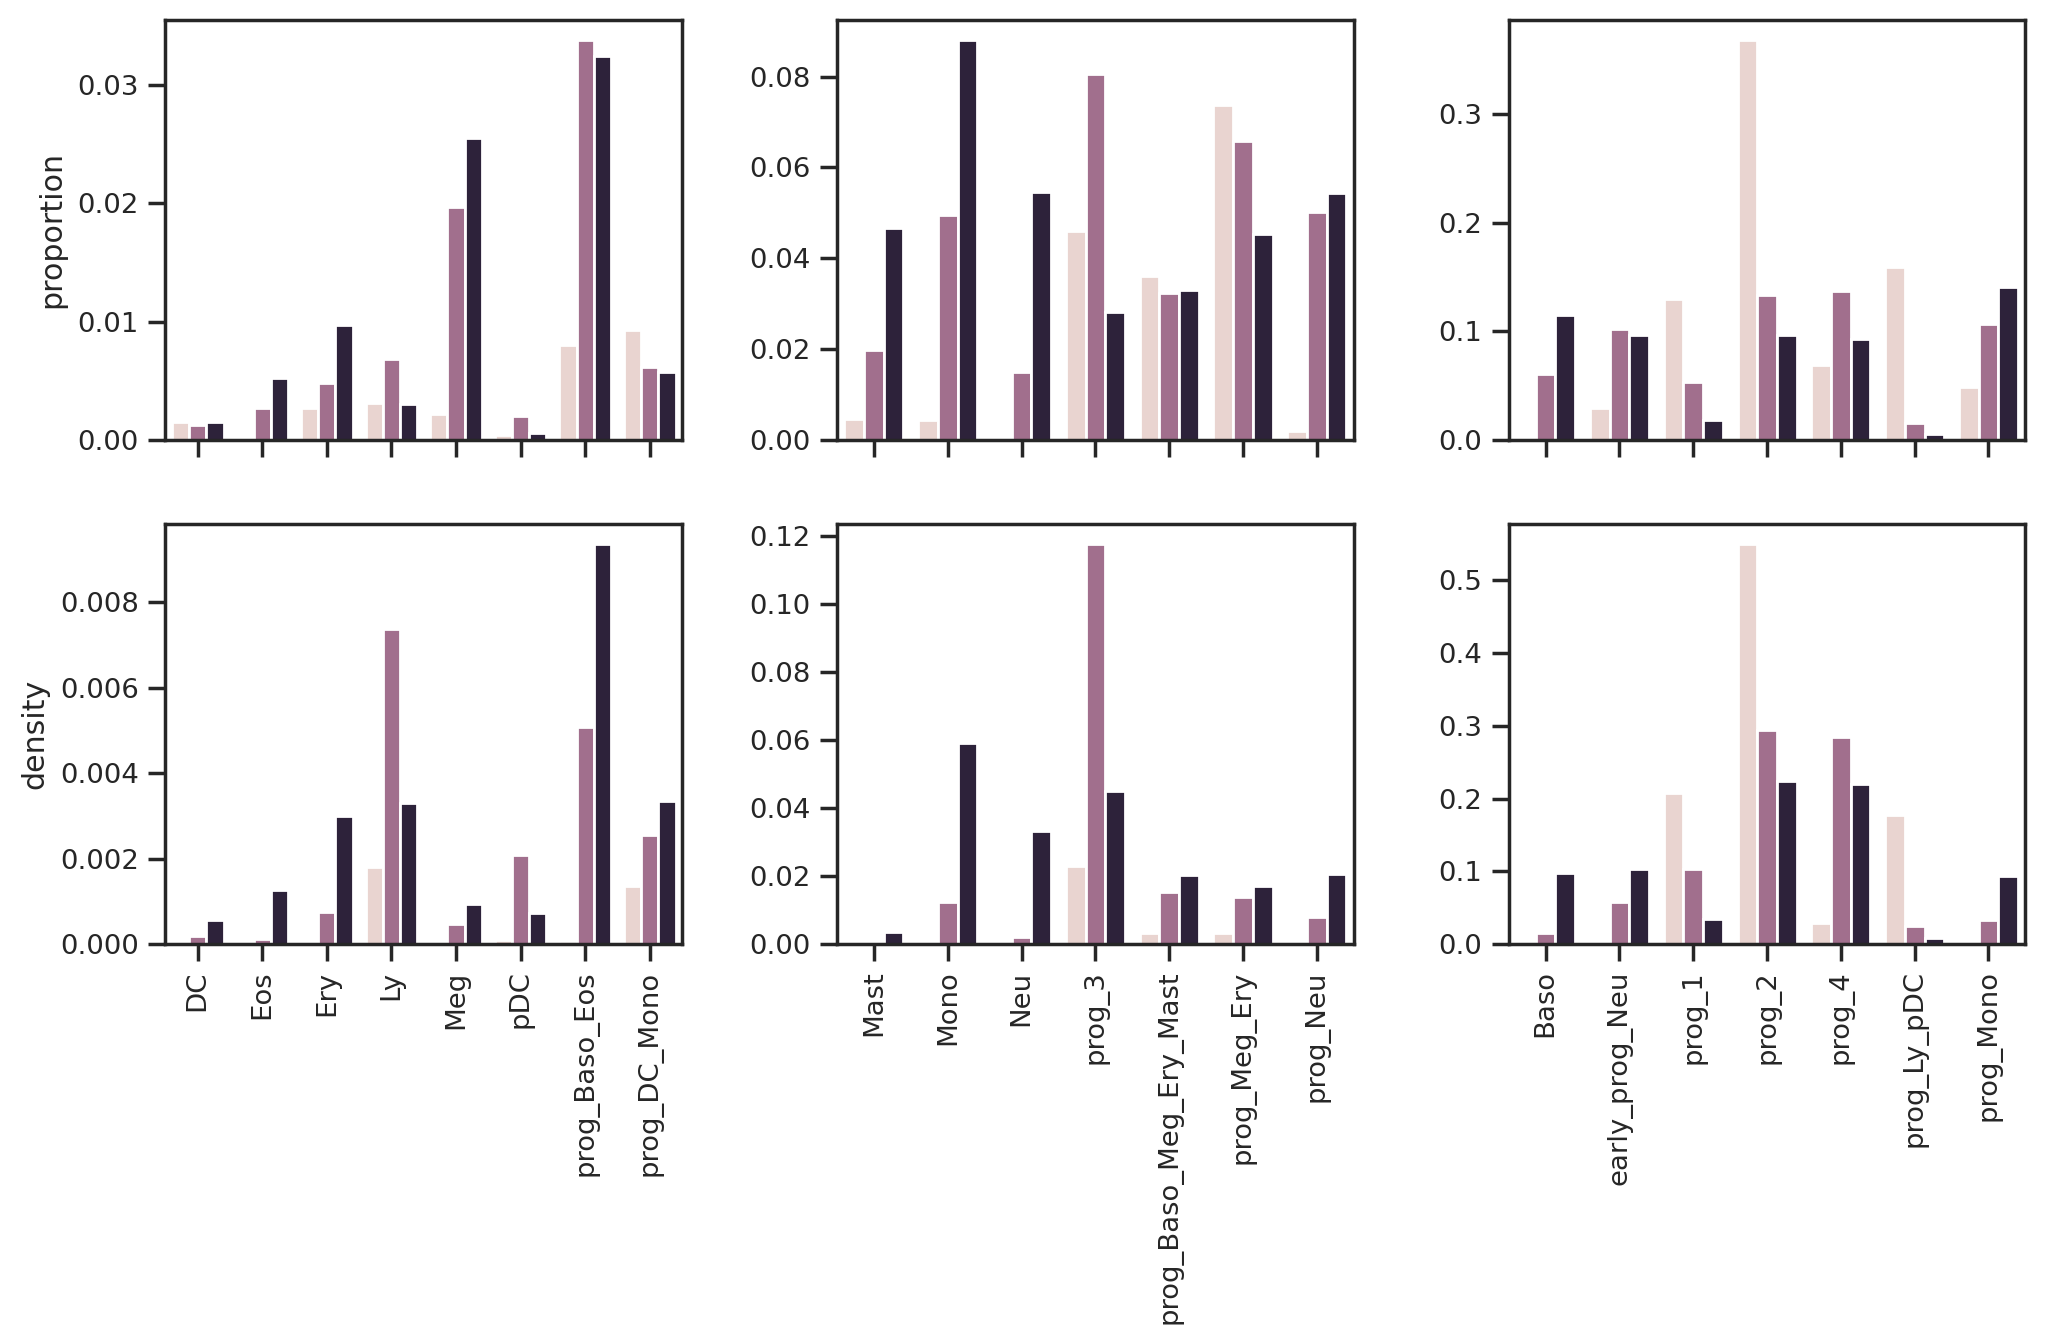

In [153]:
sns.set_theme(style='ticks', font_scale=0.9, rc={'figure.dpi':200})
fig1, fig2 = plot_proportion_density(sum_df, 'timepoint_tx_days', 'label_man');

# add deltaX

In [4]:
import scvelo as scv
import anndata as ad
from tqdm.contrib.concurrent import process_map

In [5]:
subset_up = sc.read_h5ad("data/klein_subset.h5ad")

In [67]:
addpop = sc.read_h5ad("data/klein_addpop.h5ad")

In [68]:
subset_up.uns['pop'] = addpop.uns['pop']

In [6]:
subset_up

AnnData object with n_obs × n_vars = 47907 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells', 'Day2_u', 'Day4_u', 'Day6_u', 'palantir_pseudotime', 'palantir_entropy'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'DM_EigenValues', 'Meta clones_colors', 'Population_colors', 'Time_point_colors', 'comb_colors', 'diffmap_evals', 'group_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'time_cat_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_diffmap', 'X_pca', 'X_umap', 'palantir_fate_probabilities'
    varm: 'PCs'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

In [18]:
# create new adata with DM coordinate as X
new_ad = ad.AnnData(
    X = subset_up.obsm['DM_EigenVectors_multiscaled'],
    obs = subset_up.obs.copy(),
    var = pd.DataFrame(['DM_%d'%d for d in range(5)]).set_index(0)
)

new_ad.obsp['connectivities'] = subset_up.obsp['connectivities'].copy()
new_ad.obsp['distances'] = subset_up.obsp['distances'].copy()
new_ad.layers['DM'] = new_ad.X.copy()
new_ad.obsm["X_pca"] = subset_up.obsm["X_pca"]
new_ad.obsm["X_umap"] = subset_up.obsm["X_umap"]

new_ad.uns = subset_up.uns.copy()

for key in ['v7_d2_v', 'v7_d4_v', 'v7_d6_v']:
    new_ad.layers[key] = np.load(f"results/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/{key}_highdim_v.npy")

In [45]:
delta_X, neighbor_ls = tl.sample_deltax(subset_up, xkey='DM_EigenVectors_multiscaled', progressbar=True)

deltaX = np.stack(delta_X)
neighbors = np.stack(neighbor_ls)

  4%|▍         | 1813/47907 [00:09<04:04, 188.25it/s]

100%|██████████| 47907/47907 [04:21<00:00, 183.40it/s]


In [47]:
neighbors

array([ 3582, 43144,  5127, ..., 34567, 27337,  6558])

In [51]:
def iter_fn(i):
    delta_X, neighbor_ls = tl.sample_deltax(subset_up, 
                    xkey='DM_EigenVectors_multiscaled', progressbar=False)
    deltaX = np.stack(delta_X)
    neighbors = np.stack(neighbor_ls)
    return deltaX, neighbors

tuple_list = process_map(iter_fn, np.arange(120), max_workers=60)

  0%|          | 0/120 [00:00<?, ?it/s]

In [52]:
deltaX_ts = np.stack([a[0] for a in tuple_list])
neighbor_ts = np.stack([a[1] for a in tuple_list])

In [54]:
np.save('results/Weinreb_dx/deltaX.npy', deltaX_ts)
np.save('results/Weinreb_dx/neighbors.npy', neighbor_ts)

In [59]:
scv.pp.neighbors(new_ad, n_neighbors=15)

computing neighbors
    finished (0:00:26) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)


In [58]:
deltax = deltaX_ts.mean(axis=0)
new_ad.layers['deltax'] = deltax

In [66]:
subset_up.obsm['Delta_DM'] = deltax

In [61]:
deltaX_ts.std(axis=0)

array([[5.4723140e-02, 1.5257247e-02, 7.9603726e-03, 4.5390869e-03,
        1.0891916e-04],
       [2.2999039e-03, 2.4583924e-03, 2.0070656e-03, 1.5885421e-03,
        6.9471574e-03],
       [4.4703484e-08, 8.9406967e-08, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00],
       ...,
       [3.7687155e-03, 1.4579481e-02, 1.1745846e-02, 9.6914526e-03,
        6.4377688e-05],
       [4.7720947e-05, 1.5980491e-02, 2.3842568e-02, 2.3000637e-02,
        5.5661221e-04],
       [1.3038516e-08, 0.0000000e+00, 0.0000000e+00, 1.0244548e-08,
        5.8207661e-10]], dtype=float32)

computing velocity graph (using 20/256 cores)


  0%|          | 0/47907 [00:00<?, ?cells/s]

    finished (0:00:17) --> added 
    'deltax_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:08) --> added
    'deltax_umap', embedded velocity vectors (adata.obsm)


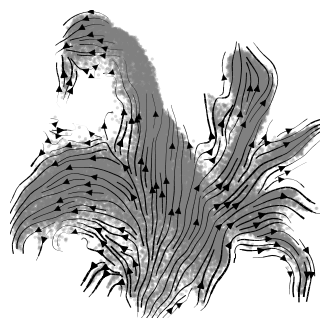

In [60]:
scv.tl.velocity_graph(new_ad, vkey='deltax', xkey='DM', n_jobs=20)
scv.pl.velocity_embedding_stream(new_ad, vkey='deltax', basis='umap',integration_direction='both')

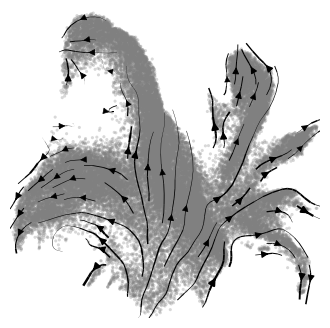

In [63]:
scv.pl.velocity_embedding_stream(new_ad, 
    density = 1,
    vkey='deltax', basis='umap',
    integration_direction='forward')

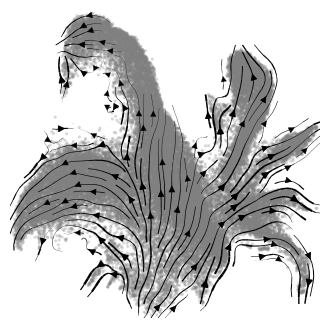

In [65]:
scv.pl.velocity_embedding_stream(new_ad, 
    density = 1.5,
    vkey='deltax', basis='umap',
    integration_direction='both')

In [69]:
subset_up.write_h5ad("data/klein_subset.h5ad")